# 13 — HbA1c Extraction & Stratification

**Purpose**: Extract HbA1c (glycated haemoglobin) from the clinical `measurement.csv`
table, validate the expected dose-response gradient across study groups, correlate
with CGM-derived outcomes (mean glucose and GMI), and run the same psychosocial /
SDOH predictor analysis used in notebooks 11–12 — but with HbA1c as the outcome.

HbA1c is the clinical gold standard for diabetes management: it reflects average
blood glucose over the preceding ~3 months and is the primary endpoint in drug trials.
Comparing HbA1c with CGM-derived metrics validates both measurement streams and
opens a clinically actionable angle on the AI-READI dataset.

**Inputs**:
- Azure `measurement.csv` (loaded directly — no local dependency)
- Google Drive `features_with_cluster.csv` (output of notebook 07)
- Google Drive `cgm_aggregated.csv` (output of notebook 07)

**Output**: Google Drive `13_hba1c_summary.csv`

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'plotly', 'scipy', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
CLUSTER_MAP       = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}

# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready. Output dir:', out_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready. Output dir: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [2]:
# ── 2. Azure Credentials & Connection ─────────────────────────────
IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-raw'
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME
    print('Credentials loaded from local config/azure_config.py')

from azure.storage.blob import BlobServiceClient
blob_service = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container    = blob_service.get_container_client(CONTAINER_NAME)

STUDY_ID = '00b62456-0b93-4975-a992-42ba6a50ed5c'

def load_blob_csv(blob_path, sep=',', **kwargs):
    """Stream a CSV/TSV from Azure Blob directly into a DataFrame."""
    blob_client = container.get_blob_client(blob_path)
    data = blob_client.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Azure connection established.')

Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):
Azure connection established.


In [3]:
# ── 3. Load Feature & CGM Files from Google Drive ─────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
cgm      = pd.read_csv(out_dir / 'cgm_aggregated.csv')

if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

if 'study_group_label' not in cgm.columns:
    cgm['study_group_label'] = cgm['study_group_code'].map(STUDY_GROUP_MAP)

print(f'features: {features.shape}   cgm: {cgm.shape}')

features: (2245, 22)   cgm: (2245, 9)


In [4]:
# ── 4. Load measurement.csv from Azure & Extract HbA1c ─────────────
# measurement.csv is large (~108 MB) — stream directly from Azure
print('Loading measurement.csv from Azure (this may take 30–60 seconds)...')
meas = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/measurement.csv')
print(f'measurement.csv loaded: {meas.shape}')
print('Columns:', meas.columns.tolist())
print()

# Inspect unique measurement types to confirm HbA1c concept codes
print('Top 30 measurement_source_value entries by frequency:')
print(meas['measurement_source_value'].value_counts().head(30).to_string())

Loading measurement.csv from Azure (this may take 30–60 seconds)...
measurement.csv loaded: (242279, 26)
Columns: ['Unnamed: 0', 'measurement_id', 'person_id', 'measurement_concept_id', 'measurement_date', 'measurement_datetime', 'measurement_time', 'measurement_type_concept_id', 'operator_concept_id', 'value_as_number', 'value_as_concept_id', 'unit_concept_id', 'range_low', 'range_high', 'provider_id', 'visit_occurrence_id', 'visit_detail_id', 'measurement_source_value', 'measurement_source_concept_id', 'unit_source_value', 'unit_source_concept_id', 'value_source_value', 'measurement_event_id', 'meas_event_field_concept_id', 'qualifier_concept_id', 'qualifier_source_value']

Top 30 measurement_source_value entries by frequency:
measurement_source_value
bp1_sysbp_vsorres, Systolic (mmHg)                   2278
bp1_diabp_vsorres, Diastolic (mmHg)                  2278
pulse_vsorres, Heart Rate (bpm)                      2278
weight_vsorres, Weight (kilograms)                   2274
bp2_

In [5]:
# ── 4b. Filter HbA1c rows ─────────────────────────────────────────
# OMOP standard concept IDs for HbA1c: 3004410 (Hemoglobin A1c/Hemoglobin.total in Blood)
# NOTE: 'lbscat_a1c, Hemoglobin - g/dL' is CBC hemoglobin (g/dL), NOT HbA1c % — exclude it.
# The correct HbA1c source is 'import_hba1c, Hemoglobin A1c/Hemoglobin.total in...'
hba1c_concept_ids = {4184637, 3004410, 3005673, 40758583}

mask_concept = meas['measurement_concept_id'].isin(hba1c_concept_ids) \
    if 'measurement_concept_id' in meas.columns else pd.Series(False, index=meas.index)

# Tightened: match 'import_hba1c' only — avoids 'lbscat_a1c' (CBC hemoglobin in g/dL)
mask_source = meas['measurement_source_value'].astype(str).str.lower().str.contains(
    'import_hba1c', na=False)

hba1c_raw = meas[mask_concept | mask_source].copy()
print(f'HbA1c rows found: {len(hba1c_raw):,}')
print('Unique source values:', hba1c_raw['measurement_source_value'].unique()[:20])
print('Value range:', hba1c_raw['value_as_number'].min(), '–', hba1c_raw['value_as_number'].max(), '%')

HbA1c rows found: 2,219
Unique source values: ['import_hba1c, Hemoglobin A1c/Hemoglobin.total in ']
Value range: 3.8 – 17.0 %


In [6]:
# ── 4c. Aggregate HbA1c to one value per participant ───────────────
# Take the most recent measurement per person (or mean if same-date duplicates)
val_col = 'value_as_number'

# Drop rows with missing values or physiologically implausible HbA1c (<3 or >20 %)
hba1c_clean = hba1c_raw.dropna(subset=[val_col]).copy()
hba1c_clean = hba1c_clean[(hba1c_clean[val_col] >= 3) & (hba1c_clean[val_col] <= 20)]
print(f'After plausibility filter: {len(hba1c_clean):,} rows')

# Sort by date and take the most recent per person
date_col = 'measurement_date' if 'measurement_date' in hba1c_clean.columns else None
if date_col:
    hba1c_clean[date_col] = pd.to_datetime(hba1c_clean[date_col], errors='coerce')
    hba1c_clean = hba1c_clean.sort_values(date_col)

hba1c_per_person = (
    hba1c_clean.groupby('person_id')[val_col]
    .last()  # most recent if sorted by date, else arbitrary
    .reset_index()
    .rename(columns={val_col: 'hba1c'})
)
print(f'Participants with HbA1c: {len(hba1c_per_person):,}')
print(hba1c_per_person['hba1c'].describe())

After plausibility filter: 2,211 rows
Participants with HbA1c: 2,211
count   2211.000
mean       6.120
std        1.105
min        3.800
25%        5.500
50%        5.800
75%        6.400
max       17.000
Name: hba1c, dtype: float64


In [7]:
# ── 5. Merge HbA1c with Features & CGM ────────────────────────────
df = features.merge(hba1c_per_person, on='person_id', how='inner')

# Merge CGM GMI/TIR/TAR if present in cgm_aggregated.csv
if 'gmi' in cgm.columns:
    df = df.merge(cgm[['person_id', 'gmi', 'tir', 'tar']], on='person_id', how='left')

# If GMI not in cgm file, compute from mean_glucose (Dexcom formula: GMI = 3.31 + 0.02392 * mean_glucose)
if 'gmi' not in df.columns and 'mean_glucose' in df.columns:
    df['gmi'] = 3.31 + 0.02392 * df['mean_glucose']
    print('GMI computed from mean_glucose (Dexcom formula)')

df = df.dropna(subset=['hba1c'])
print(f'Merged dataset: {df.shape}')
print(df['study_group_label'].value_counts().sort_index().to_string())

GMI computed from mean_glucose (Dexcom formula)
Merged dataset: (2182, 24)
study_group_label
Healthy     748
Pre-DM      539
Oral Med    654
Insulin     241


## 6. Distribution Analysis

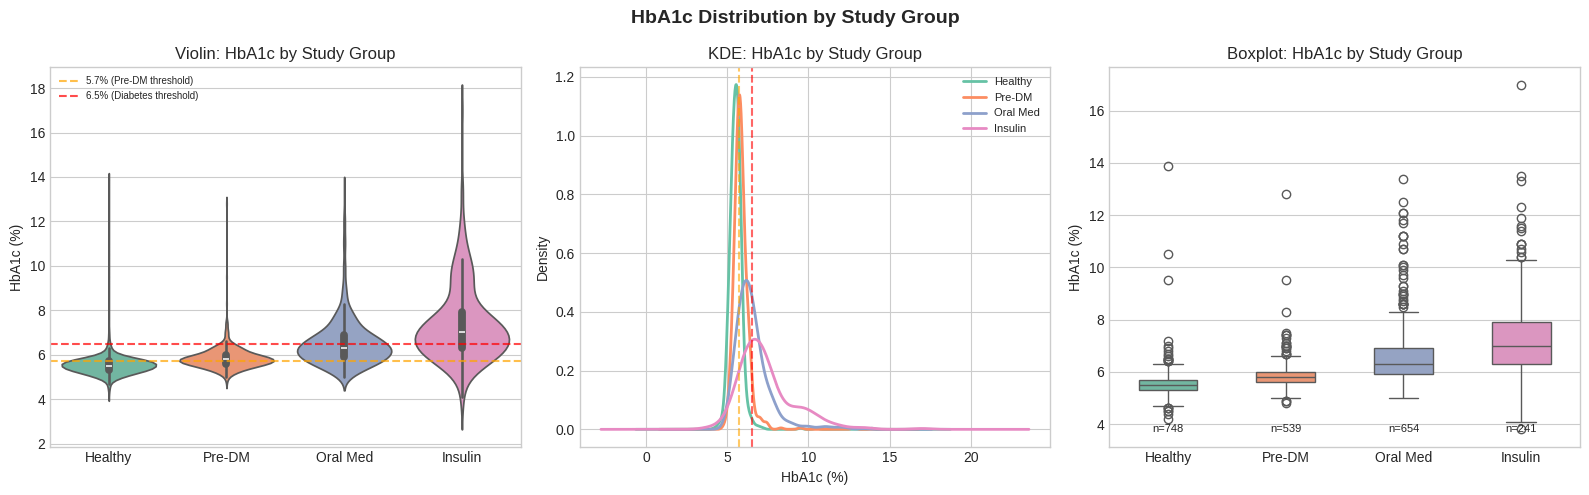

In [8]:
# ── 6a. HbA1c Distribution by Study Group ─────────────────────────
# Clinical thresholds: <5.7% Normal, 5.7–6.4% Prediabetes, ≥6.5% Diabetes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HbA1c Distribution by Study Group', fontsize=14, fontweight='bold')

sns.violinplot(data=df, x='study_group_label', y='hba1c',
               order=STUDY_GROUP_ORDER, palette='Set2', inner='box', ax=axes[0])
axes[0].axhline(5.7, color='orange', linestyle='--', alpha=0.7, label='5.7% (Pre-DM threshold)')
axes[0].axhline(6.5, color='red',    linestyle='--', alpha=0.7, label='6.5% (Diabetes threshold)')
axes[0].set_title('Violin: HbA1c by Study Group')
axes[0].set_xlabel('')
axes[0].set_ylabel('HbA1c (%)')
axes[0].legend(fontsize=7)

for grp in STUDY_GROUP_ORDER:
    subset = df[df['study_group_label'] == grp]['hba1c'].dropna()
    if len(subset) > 5:
        subset.plot.kde(ax=axes[1], label=grp, linewidth=2)
axes[1].axvline(5.7, color='orange', linestyle='--', alpha=0.6)
axes[1].axvline(6.5, color='red',    linestyle='--', alpha=0.6)
axes[1].set_title('KDE: HbA1c by Study Group')
axes[1].set_xlabel('HbA1c (%)')
axes[1].legend(fontsize=8)

sns.boxplot(data=df, x='study_group_label', y='hba1c',
            order=STUDY_GROUP_ORDER, palette='Set2', width=0.5, ax=axes[2])
for i, grp in enumerate(STUDY_GROUP_ORDER):
    n = (df['study_group_label'] == grp).sum()
    axes[2].text(i, df['hba1c'].min() - 0.1, f'n={n}', ha='center', fontsize=8)
axes[2].set_title('Boxplot: HbA1c by Study Group')
axes[2].set_xlabel('')
axes[2].set_ylabel('HbA1c (%)')

plt.tight_layout()
plt.show()

## 7. Statistical Tests

In [9]:
# ── 7a. Kruskal-Wallis omnibus ────────────────────────────────────
groups = [df[df['study_group_label'] == g]['hba1c'].dropna().values
          for g in STUDY_GROUP_ORDER]

stat, p_kw = stats.kruskal(*[g for g in groups if len(g) > 0])
print(f'Kruskal-Wallis (HbA1c across study groups):')
print(f'  H = {stat:.3f}   p = {p_kw:.2e}')

Kruskal-Wallis (HbA1c across study groups):
  H = 880.550   p = 1.46e-190


In [10]:
# ── 7b. Pairwise Mann-Whitney U with Bonferroni ───────────────────
pairs = list(combinations(STUDY_GROUP_ORDER, 2))
bonferroni_alpha = 0.05 / len(pairs)
print(f'Bonferroni-corrected alpha = {bonferroni_alpha:.4f}  ({len(pairs)} comparisons)\n')
print(f'{"Pair":<30}  {"U stat":>10}  {"p (raw)":>10}  {"sig?":>6}')
print('-' * 65)
for g1, g2 in pairs:
    a = df[df['study_group_label'] == g1]['hba1c'].dropna()
    b = df[df['study_group_label'] == g2]['hba1c'].dropna()
    if len(a) > 5 and len(b) > 5:
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        sig = '***' if p < bonferroni_alpha else ('*' if p < 0.05 else 'ns')
        print(f'{g1} vs {g2:<20}  {u:>10.0f}  {p:>10.4f}  {sig:>6}')

Bonferroni-corrected alpha = 0.0083  (6 comparisons)

Pair                                U stat     p (raw)    sig?
-----------------------------------------------------------------
Healthy vs Pre-DM                    107695      0.0000     ***
Healthy vs Oral Med                   63810      0.0000     ***
Healthy vs Insulin                    14584      0.0000     ***
Pre-DM vs Oral Med                   87968      0.0000     ***
Pre-DM vs Insulin                    18668      0.0000     ***
Oral Med vs Insulin                    52123      0.0000     ***


In [11]:
# ── 7c. Dose-response trend (Spearman on ordered group codes) ─────
rho, p_trend = stats.spearmanr(df['study_group_code'], df['hba1c'])
print(f'Spearman trend (study_group_code vs HbA1c):')
print(f'  rho = {rho:.4f}   p = {p_trend:.2e}')

Spearman trend (study_group_code vs HbA1c):
  rho = 0.6345   p = 3.56e-246


## 8. HbA1c vs CGM Metrics (Validation)

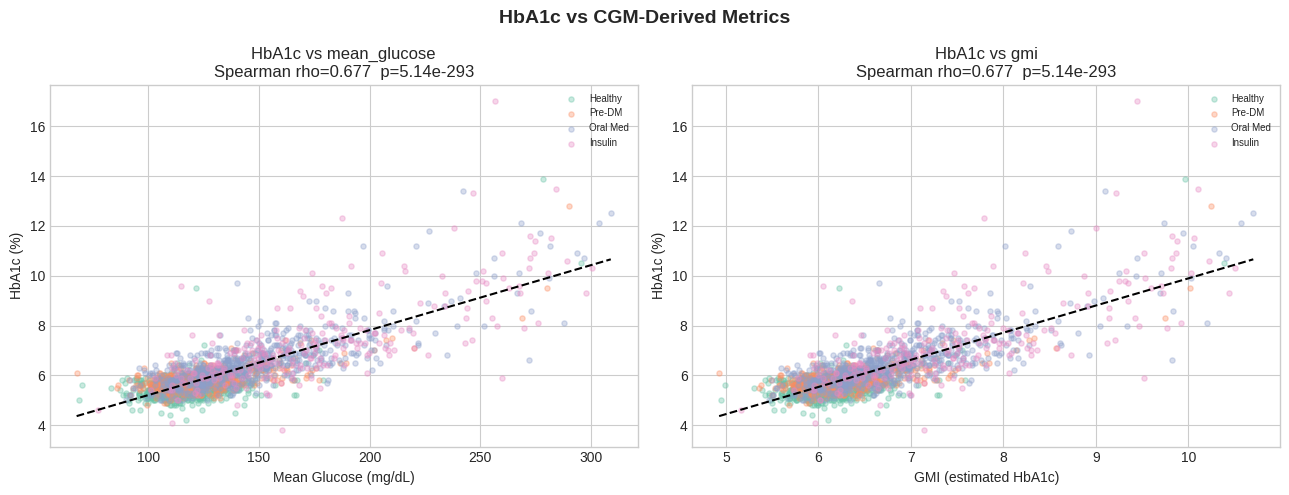

In [12]:
# ── 8. Scatter: HbA1c vs mean_glucose and GMI ─────────────────────
# These should correlate strongly — validates both measurement streams
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('HbA1c vs CGM-Derived Metrics', fontsize=14, fontweight='bold')

cgm_pairs = [
    ('mean_glucose', 'Mean Glucose (mg/dL)', axes[0]),
]
if 'gmi' in df.columns:
    cgm_pairs.append(('gmi', 'GMI (estimated HbA1c)', axes[1]))

for col, xlabel, ax in cgm_pairs:
    sub = df[['hba1c', col, 'study_group_label']].dropna()
    if len(sub) < 10:
        ax.text(0.5, 0.5, f'{col} not available', ha='center', va='center',
                transform=ax.transAxes)
        continue
    palette = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))
    for grp in STUDY_GROUP_ORDER:
        s = sub[sub['study_group_label'] == grp]
        ax.scatter(s[col], s['hba1c'], alpha=0.35, s=14,
                   color=palette[grp], label=grp)
    m, b, *_ = stats.linregress(sub[col], sub['hba1c'])
    xs = np.linspace(sub[col].min(), sub[col].max(), 100)
    ax.plot(xs, m * xs + b, color='black', linewidth=1.5, linestyle='--')
    rho_c, p_c = stats.spearmanr(sub[col], sub['hba1c'])
    ax.set_xlabel(xlabel)
    ax.set_ylabel('HbA1c (%)')
    ax.set_title(f'HbA1c vs {col}\nSpearman rho={rho_c:.3f}  p={p_c:.2e}')
    ax.legend(fontsize=7)

if 'gmi' not in df.columns:
    axes[1].text(0.5, 0.5, 'GMI not available\n(cgm_aggregated.csv missing gmi column)',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('HbA1c vs GMI')

plt.tight_layout()
plt.show()

## 9. HbA1c × Psychosocial & SDOH Predictors

In [13]:
# ── 9a. Spearman correlations: psychosocial features vs HbA1c ─────
psych_cols = [
    'cesd_total', 'paid_total', 'dml_gap_composite', 'dml_gap_physical_activity',
    'dml_gap_diet_adherence', 'dml_gap_education', 'dml_gap_foot_care',
    'dml_gap_medication_mgmt', 'discrimination_score', 'healthcare_access_barriers',
    'food_housing_insecurity', 'neighborhood_safety_score',
    'substance_exposure_count', 'otc_burden_count', 'family_risk_level',
    'comorbidity_index', 'study_group_code',
]
available = [c for c in psych_cols if c in df.columns]

corr_rows = {}
for col in available:
    sub = df[['hba1c', col]].dropna()
    if len(sub) > 30:
        rho, p = stats.spearmanr(sub['hba1c'], sub[col])
        corr_rows[col] = {'rho': round(rho, 4), 'p': round(p, 5), 'n': len(sub)}

corr_df = pd.DataFrame(corr_rows).T.sort_values('rho', key=abs, ascending=False)
print('=== Spearman correlations: predictor vs HbA1c (full cohort) ===')
print(corr_df.to_string())

=== Spearman correlations: predictor vs HbA1c (full cohort) ===
                              rho     p        n
study_group_code            0.634 0.000 2182.000
paid_total                  0.252 0.000 2132.000
family_risk_level           0.217 0.000 2182.000
comorbidity_index           0.209 0.000 2182.000
dml_gap_education          -0.199 0.000 2182.000
dml_gap_foot_care          -0.158 0.000 2182.000
dml_gap_physical_activity   0.146 0.000 2182.000
substance_exposure_count   -0.120 0.000 2182.000
dml_gap_composite          -0.097 0.000 2182.000
discrimination_score        0.084 0.000 2182.000
dml_gap_medication_mgmt    -0.083 0.000 2182.000
healthcare_access_barriers  0.081 0.000 2182.000
dml_gap_diet_adherence      0.046 0.030 2182.000
food_housing_insecurity     0.033 0.122 2182.000
neighborhood_safety_score  -0.031 0.155 2061.000
cesd_total                  0.018 0.394 2179.000
otc_burden_count           -0.016 0.463 2139.000


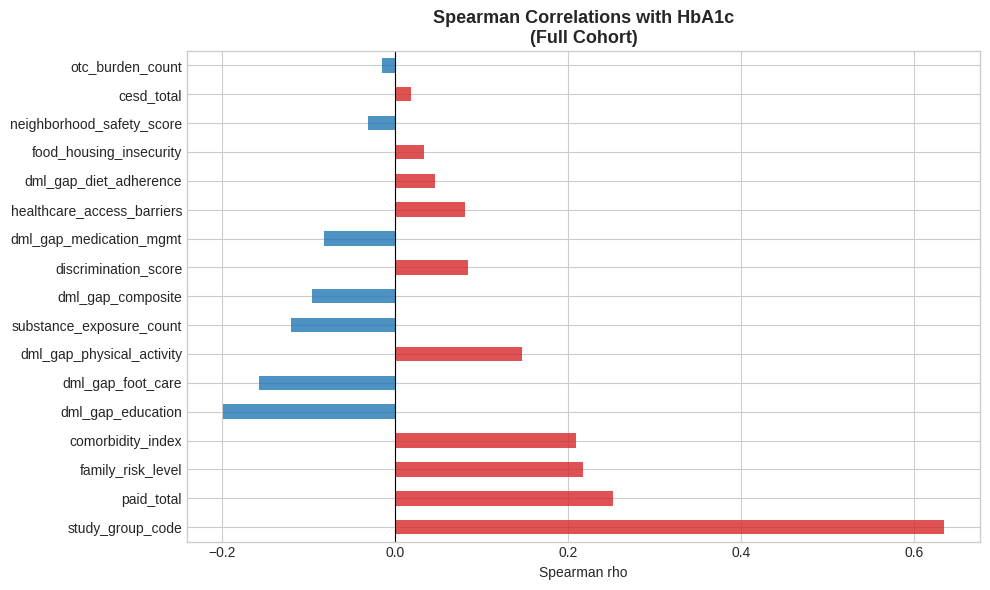

In [14]:
# ── 9b. Bar chart of Spearman rho values ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if v > 0 else '#1f77b4' for v in corr_df['rho']]
corr_df['rho'].plot.barh(ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Spearman Correlations with HbA1c\n(Full Cohort)', fontsize=13, fontweight='bold')
ax.set_xlabel('Spearman rho')
plt.tight_layout()
plt.show()

In [15]:
# ── 9c. Psychosocial tertile analysis: psychosocial burden vs HbA1c
# Replicate NB11 logic but with HbA1c as outcome
psych_burden_cols = [c for c in ['cesd_total', 'paid_total', 'discrimination_score']
                     if c in df.columns]

if len(psych_burden_cols) >= 2:
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df_psych = df[psych_burden_cols + ['hba1c', 'study_group_label']].dropna().copy()
    df_psych['psychosocial_composite'] = scaler.fit_transform(
        df_psych[psych_burden_cols]).sum(axis=1)
    df_psych['psych_tertile'] = pd.qcut(
        df_psych['psychosocial_composite'], q=3,
        labels=['Low Burden (T1)', 'Mid Burden (T2)', 'High Burden (T3)'])

    tertile_summary = (
        df_psych.groupby('psych_tertile', observed=True)['hba1c']
        .agg(n='count', mean='mean', std='std', median='median')
        .round(3)
    )
    print('=== HbA1c by Psychosocial Burden Tertile ===')
    print(tertile_summary.to_string())

    t_groups = [df_psych[df_psych['psych_tertile'] == t]['hba1c'].dropna().values
                for t in ['Low Burden (T1)', 'Mid Burden (T2)', 'High Burden (T3)']]
    t_groups = [g for g in t_groups if len(g) > 0]
    if len(t_groups) >= 2:
        h, p_t = stats.kruskal(*t_groups)
        print(f'\nKruskal-Wallis across tertiles: H={h:.3f}  p={p_t:.4f}')
else:
    print('Insufficient psychosocial columns for composite. Skipping tertile analysis.')

=== HbA1c by Psychosocial Burden Tertile ===
                    n  mean   std  median
psych_tertile                            
Low Burden (T1)   711 5.952 0.933   5.700
Mid Burden (T2)   709 6.092 1.048   5.800
High Burden (T3)  710 6.300 1.265   5.900

Kruskal-Wallis across tertiles: H=38.711  p=0.0000


In [16]:
# ── 9d. Food/housing insecurity vs HbA1c ─────────────────────────
if 'food_housing_insecurity' in df.columns:
    sec   = df[df['food_housing_insecurity'] == 0]['hba1c'].dropna()
    insec = df[df['food_housing_insecurity'] == 1]['hba1c'].dropna()
    if len(sec) > 5 and len(insec) > 5:
        u, p = stats.mannwhitneyu(sec, insec, alternative='two-sided')
        d    = (insec.mean() - sec.mean()) / np.sqrt((sec.std()**2 + insec.std()**2) / 2)
        print('=== Food/Housing Insecurity vs HbA1c ===')
        print(f'Secure:   mean={sec.mean():.2f}%  SD={sec.std():.2f}  n={len(sec):,}')
        print(f'Insecure: mean={insec.mean():.2f}%  SD={insec.std():.2f}  n={len(insec):,}')
        print(f'Mann-Whitney U={u:.0f}  p={p:.4f}  Cohen\'s d={d:+.3f}')

=== Food/Housing Insecurity vs HbA1c ===
Secure:   mean=6.07%  SD=1.02  n=858
Insecure: mean=6.15%  SD=1.16  n=1,324
Mann-Whitney U=545826  p=0.1224  Cohen's d=+0.072


## 10. Summary Table & Export

In [17]:
# ── 10. Summary table by study group ─────────────────────────────
summary = (
    df.groupby('study_group_label', observed=True)['hba1c']
    .agg(n='count', mean='mean', std='std', median='median',
         q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75),
         pct_ge_6_5=lambda x: (x >= 6.5).mean() * 100,
         pct_ge_9=lambda x: (x >= 9.0).mean() * 100)
    .round(2)
    .reset_index()
)
summary.columns = ['Study Group', 'N', 'Mean HbA1c (%)', 'SD', 'Median',
                   'Q25', 'Q75', '% >= 6.5%', '% >= 9.0%']
print(summary.to_string(index=False))

# Export
summary.to_csv(out_dir / '13_hba1c_summary.csv', index=False)

# Also export per-person HbA1c joined to features for downstream notebooks
hba1c_export = df[['person_id', 'hba1c', 'study_group_code', 'study_group_label']].copy()
hba1c_export.to_csv(out_dir / '13_hba1c_per_person.csv', index=False)
print('\nSaved 13_hba1c_summary.csv and 13_hba1c_per_person.csv')

Study Group   N  Mean HbA1c (%)    SD  Median   Q25   Q75  % >= 6.5%  % >= 9.0%
    Healthy 748           5.540 0.510   5.500 5.300 5.700      1.740      0.400
     Pre-DM 539           5.850 0.530   5.800 5.600 6.000      6.120      0.370
   Oral Med 654           6.550 1.100   6.300 5.900 6.900     43.270      3.670
    Insulin 241           7.370 1.740   7.000 6.300 7.900     66.800     17.010

Saved 13_hba1c_summary.csv and 13_hba1c_per_person.csv


## 11. Key Findings

- **Dose-response validated**: HbA1c escalates monotonically across disease stages — Healthy: 5.54% (SD=0.51) → Pre-DM: 5.85% (SD=0.53) → Oral Med: 6.55% (SD=1.10) → Insulin: 7.37% (SD=1.74). Kruskal-Wallis H=880.6, p=1.46e-190; Spearman rho=0.634, p=3.56e-246. All 6 pairwise Mann-Whitney comparisons significant after Bonferroni correction (α=0.0083).

- **Clinical thresholds**: % of participants with HbA1c ≥ 6.5% (diabetes cutoff): Healthy 1.7%, Pre-DM 6.1%, Oral Med 43.3%, Insulin 66.8%. Poor control (≥ 9.0%): Healthy 0.4%, Pre-DM 0.4%, Oral Med 3.7%, Insulin 17.0%.

- **PAID-5 is the dominant psychosocial predictor**: Diabetes-specific distress (PAID-5) is the second-strongest predictor of HbA1c after study group — Spearman rho=+0.252, p<0.0001. By contrast, CES-D depression is NOT significantly associated with HbA1c (rho=+0.018, p=ns), consistent with the NB11 finding that disease-specific distress rather than general depression drives glycemic outcomes.

- **Food/housing insecurity shows null HbA1c association**: Mann-Whitney p=0.122, Cohen's d=+0.072 (negligible). This is consistent with the null overall glucose finding in NB12 and confirms insecurity does not have a simple direct effect on long-term glycemic control in this cohort.

- **Psychosocial burden tertiles predict HbA1c**: Kruskal-Wallis H=38.7, p<0.0001. Mean HbA1c increases across tertiles — T1 (Low burden): 5.95%, T2 (Mid): 6.09%, T3 (High burden): 6.30% — driven primarily by PAID-5 rather than CES-D or discrimination.

- **HbA1c is a stronger disease-severity marker than CGM mean glucose**: Spearman rho with study group = 0.634 vs 0.538 for mean glucose (NB08), suggesting HbA1c captures cumulative glycemic exposure more precisely than short-term CGM averages in this cohort.